In [28]:
#Connexion de Python à MySQL avec SQLAlchemy (Connexion de Python à MySQL avec SQLAlchemy)
%pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [29]:
import mysql.connector

In [30]:
print("Connexion MySQL prête")

Connexion MySQL prête


In [31]:
import sqlalchemy

print("SQLAlchemy version :", sqlalchemy.__version__)

SQLAlchemy version : 2.0.43


In [32]:
utilisateur = "root"
mot_de_passe = "Sofyanobayd1234@"
hote = "127.0.0.1"
port = 3306

print("Utilisateur :", utilisateur)
print("Host :", hote)
print("Port :", port)

Utilisateur : root
Host : 127.0.0.1
Port : 3306


In [33]:
import pymysql

connexion = pymysql.connect(
    host=hote,
    user=utilisateur,
    password=mot_de_passe,
    port=port
)

print("Connexion à MySQL réussie.")

Connexion à MySQL réussie.


In [34]:
connexion.close()

print("Connexion fermée.")

Connexion fermée.


In [35]:
connexion = pymysql.connect(
    host=hote,
    user=utilisateur,
    password=mot_de_passe,
    port=port
)

curseur = connexion.cursor()

curseur.execute("SHOW DATABASES")

databases = curseur.fetchall()

for database in databases:
    print(database[0])

connexion.close()

bank_churn_analysis
banking_analysis
company
hr
information_schema
medical
mysql
performance_schema
petrescue_db
sys


In [36]:
base_de_donnees = "bank_churn_analysis"

connexion = pymysql.connect(
    host=hote,
    user=utilisateur,
    password=mot_de_passe,
    port=port,
    database=base_de_donnees
)

curseur = connexion.cursor()

curseur.execute("SHOW TABLES")

tables = curseur.fetchall()

for table in tables:
    print(table[0])

connexion.close()

bank_clients


In [37]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [38]:
connection_url = URL.create(
    drivername="mysql+pymysql",
    username=utilisateur,
    password=mot_de_passe,
    host=hote,
    port=port,
    database=base_de_donnees
)

engine = create_engine(connection_url)

print("SQLAlchemy engine créé.")

SQLAlchemy engine créé.


In [39]:
import pandas as pd

df = pd.read_sql(
    "SELECT * FROM bank_clients",
    engine
)

print("Importation réussie.")
print("Dimensions :", df.shape)

Importation réussie.
Dimensions : (10000, 13)


In [40]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
0,15565701,Ferri,698,Spain,Female,39,9,161993.89,1,0,0,90212.38,0
1,15565706,Akobundu,612,Spain,Male,35,1,0.00,1,1,1,83256.26,1
2,15565714,Cattaneo,601,France,Male,47,1,64430.06,2,0,1,96517.97,0
3,15565779,Kent,627,Germany,Female,30,6,57809.32,1,1,0,188258.49,0
4,15565796,Docherty,745,Germany,Male,48,10,96048.55,1,1,0,74510.65,0


In [41]:
df.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
9995,15815628,Moysey,711,France,Female,37,8,113899.92,1,0,0,80215.20,0
9996,15815645,Akhtar,481,France,Male,37,8,152303.66,2,1,1,175082.20,0
9997,15815656,Hopkins,541,Germany,Female,39,9,100116.67,1,1,1,199808.10,1
9998,15815660,Mazzi,758,France,Female,34,1,154139.45,1,1,1,60728.89,0
9999,15815690,Akabueze,614,Spain,Female,40,3,113348.50,1,1,1,77789.01,0


In [42]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num_Of_Products   10000 non-null  int64  
 9   Has_Credit_Card   10000 non-null  int64  
 10  Is_Active_Member  10000 non-null  int64  
 11  Estimated_Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [44]:
df.dtypes

CustomerId            int64
Surname              object
CreditScore           int64
Geography            object
Gender               object
Age                   int64
Tenure                int64
Balance             float64
Num_Of_Products       int64
Has_Credit_Card       int64
Is_Active_Member      int64
Estimated_Salary    float64
Churn                 int64
dtype: object

In [45]:
dictionnaire = pd.DataFrame({
    "Variable": [
        "CustomerId",
        "Surname",
        "CreditScore",
        "Geography",
        "Gender",
        "Age",
        "Tenure",
        "Balance",
        "Num_Of_Products",
        "Has_Credit_Card",
        "Is_Active_Member",
        "Estimated_Salary",
        "Churn"
    ],
    "Description": [
        "Identifiant du client",
        "Nom du client",
        "Score de crédit",
        "Pays du client",
        "Genre",
        "Âge",
        "Ancienneté bancaire",
        "Solde du compte",
        "Nombre de produits bancaires",
        "Possession d'une carte bancaire",
        "Client actif ou non",
        "Salaire estimé",
        "Départ du client"
    ]
})

dictionnaire

,Variable,Description
0,CustomerId,Identifiant du client
1,Surname,Nom du client
2,CreditScore,Score de crédit
3,Geography,Pays du client
4,Gender,Genre
5,Age,Âge
6,Tenure,Ancienneté bancaire
7,Balance,Solde du compte
8,Num_Of_Products,Nombre de produits bancaires
9,Has_Credit_Card,Possession d'une carte bancaire


In [46]:
valeurs_manquantes = df.isnull().sum()

print(valeurs_manquantes)

CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
Num_Of_Products     0
Has_Credit_Card     0
Is_Active_Member    0
Estimated_Salary    0
Churn               0
dtype: int64


In [47]:
pourcentage_manquant = (
    df.isnull().sum() / len(df) * 100
).round(2)

table_manquants = pd.DataFrame({
    "Valeurs manquantes": df.isnull().sum(),
    "Pourcentage (%)": pourcentage_manquant
})

table_manquants

,Valeurs manquantes,Pourcentage (%)
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
Num_Of_Products,0,0.0
Has_Credit_Card,0,0.0


La base ne présente pas de valeurs manquantes.

In [48]:
nombre_doublons = df.duplicated().sum()

print("Nombre de doublons :", nombre_doublons)

Nombre de doublons : 0


# Statistiques descriptives

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
Num_Of_Products,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
Has_Credit_Card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
Is_Active_Member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
Estimated_Salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
Churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


In [50]:
statistiques = df[
    [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "Num_Of_Products",
        "Estimated_Salary"
    ]
].describe().T

statistiques

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
Num_Of_Products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
Estimated_Salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


# Analyse de la variable cible

In [51]:
df["Churn"].value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

In [52]:
attrition = (
    df["Churn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

attrition

Churn
0    79.63
1    20.37
Name: proportion, dtype: float64

In [53]:
table_attrition = pd.DataFrame({
    "Statut": ["Client resté", "Client parti"],
    "Nombre": [
        (df["Churn"] == 0).sum(),
        (df["Churn"] == 1).sum()
    ]
})

table_attrition["Pourcentage (%)"] = (
    table_attrition["Nombre"] / len(df) * 100
).round(2)

table_attrition

,Statut,Nombre,Pourcentage (%)
0,Client resté,7963,79.63
1,Client parti,2037,20.37


# Visualisation de l’attrition

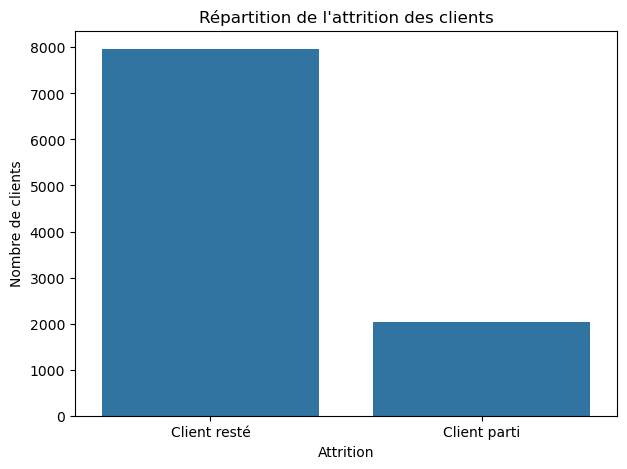

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Répartition de l'attrition des clients")
plt.xlabel("Attrition")
plt.ylabel("Nombre de clients")

plt.xticks(
    [0, 1],
    ["Client resté", "Client parti"]
)

plt.show()

- Cette visualisation permet de comparer directement le nombre de clients restés avec le nombre de clients ayant quitté la banque.

# Attrition selon le genre

In [55]:
attrition_genre = pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
) * 100

attrition_genre.round(2)

Churn,0,1
Gender,,
Female,74.93,25.07
Male,83.54,16.46


In [56]:
taux_attrition_genre = (
    df.groupby("Gender")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

taux_attrition_genre

Gender
Female    25.07
Male      16.46
Name: Churn, dtype: float64

# Attrition selon la géographie

In [57]:
taux_attrition_geographie = (
    df.groupby("Geography")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

taux_attrition_geographie

Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Churn, dtype: float64

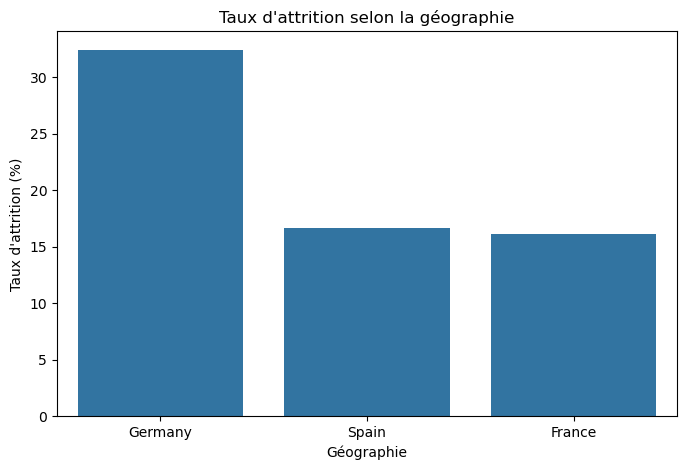

In [80]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=taux_attrition_geographie.index,
    y=taux_attrition_geographie.values
)

plt.title("Taux d'attrition selon la géographie")
plt.xlabel("Géographie")
plt.ylabel("Taux d'attrition (%)")

plt.show()

- On observe une différence du taux d’attrition entre les zones géographiques, mais cette différence décrit une association et ne permet pas à elle seule de conclure à une relation causale

# Attrition selon l’âge

In [59]:
age_attrition = (
    df.groupby("Churn")["Age"]
    .mean()
    .round(2)
)

age_attrition

Churn
0    37.41
1    44.84
Name: Age, dtype: float64

In [60]:
df["Categorie_Age"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[
        "Moins de 30 ans",
        "30-39 ans",
        "40-49 ans",
        "50-59 ans",
        "60 ans et plus"
    ]
)
taux_attrition_age = (
    df.groupby("Categorie_Age", observed=True)["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

taux_attrition_age

Categorie_Age
Moins de 30 ans     7.52
30-39 ans          12.09
40-49 ans          33.97
50-59 ans          56.21
60 ans et plus     24.78
Name: Churn, dtype: float64

# Analyse du CreditScore

In [61]:
score_attrition = (
    df.groupby("Churn")["CreditScore"]
    .mean()
    .round(2)
)

score_attrition

Churn
0    651.85
1    645.35
Name: CreditScore, dtype: float64

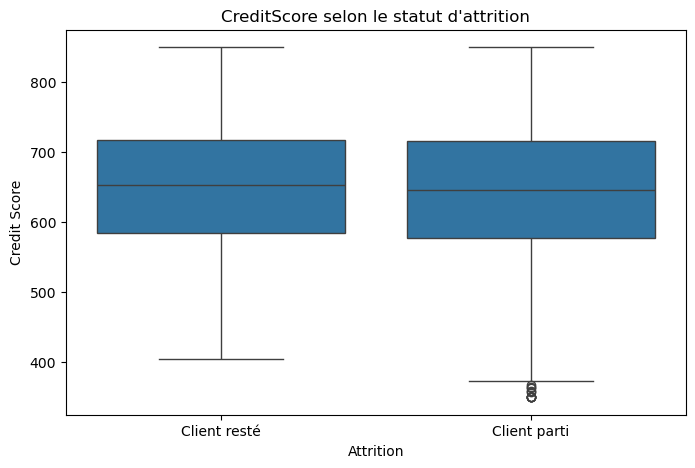

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="CreditScore"
)

plt.title("CreditScore selon le statut d'attrition")
plt.xlabel("Attrition")
plt.ylabel("Credit Score")

plt.xticks(
    [0, 1],
    ["Client resté", "Client parti"]
)

plt.show()

# Balance

In [63]:
balance_attrition = (
    df.groupby("Churn")["Balance"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

balance_attrition

,mean,median,min,max
Churn,,,,
0,72745.30,92072.68,0.0,221532.80
1,91108.54,109349.29,0.0,250898.09


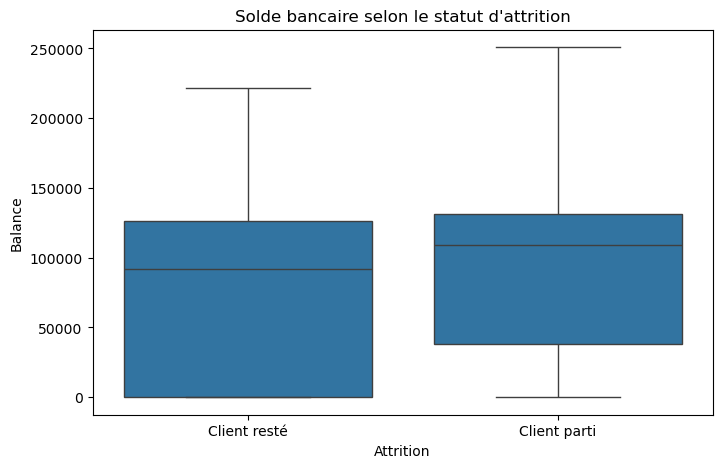

In [82]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Balance"
)

plt.title("Solde bancaire selon le statut d'attrition")
plt.xlabel("Attrition")
plt.ylabel("Balance")

plt.xticks(
    [0, 1],
    ["Client resté", "Client parti"]
)

plt.show()

# Activité du client

In [65]:
attrition_activite = (
    df.groupby("Is_Active_Member")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

attrition_activite

Is_Active_Member
0    26.85
1    14.27
Name: Churn, dtype: float64

In [66]:
df["Statut_Activite"] = df["Is_Active_Member"].map({
    0: "Client non actif",
    1: "Client actif"
})
taux_activite = (
    df.groupby("Statut_Activite")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

taux_activite

Statut_Activite
Client non actif    26.85
Client actif        14.27
Name: Churn, dtype: float64

# Nombre de produits

In [67]:
attrition_produits = (
    df.groupby("Num_Of_Products")["Churn"]
    .agg(["count", "mean"])
)

attrition_produits["Taux_attrition_%"] = (
    attrition_produits["mean"] * 100
).round(2)

attrition_produits

,count,mean,Taux_attrition_%
Num_Of_Products,,,
1,5084,0.277144,27.71
2,4590,0.075817,7.58
3,266,0.827068,82.71
4,60,1.000000,100.00


# Credit Card

In [68]:
attrition_carte = (
    df.groupby("Has_Credit_Card")["Churn"]
    .mean()
    .mul(100)
    .round(2)
)

attrition_carte

Has_Credit_Card
0    20.81
1    20.18
Name: Churn, dtype: float64

# Tenure

In [69]:
attrition_tenure = (
    df.groupby("Tenure")["Churn"]
    .agg(["count", "mean"])
)

attrition_tenure["Taux_attrition_%"] = (
    attrition_tenure["mean"] * 100
).round(2)

attrition_tenure

,count,mean,Taux_attrition_%
Tenure,,,
0,413,0.230024,23.00
1,1035,0.224155,22.42
2,1048,0.191794,19.18
3,1009,0.211100,21.11
4,989,0.205258,20.53
5,1012,0.206522,20.65
6,967,0.202689,20.27
7,1028,0.172179,17.22
8,1025,0.192195,19.22


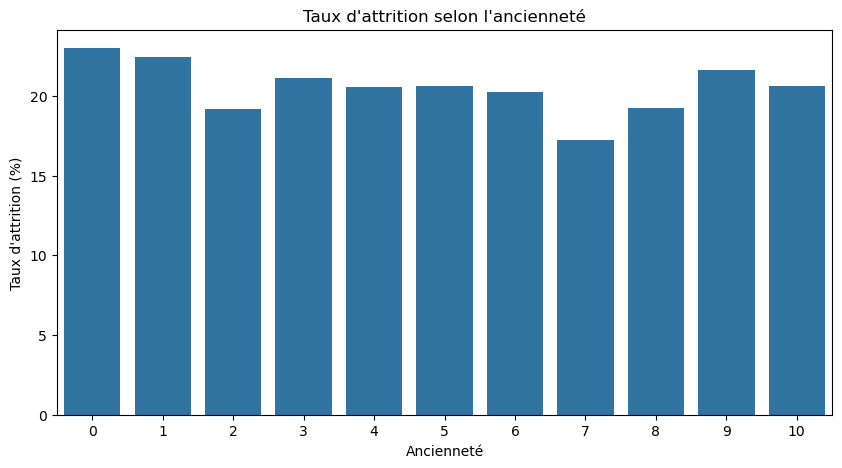

In [83]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=attrition_tenure.reset_index(),
    x="Tenure",
    y="Taux_attrition_%"
)

plt.title("Taux d'attrition selon l'ancienneté")
plt.xlabel("Ancienneté")
plt.ylabel("Taux d'attrition (%)")

plt.show()

# Corrélations numériques

In [84]:
variables_numeriques = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "Num_Of_Products",
    "Estimated_Salary",
    "Churn"
]

matrice_correlation = df[variables_numeriques].corr()

matrice_correlation.round(2)

,CreditScore,Age,Tenure,Balance,Num_Of_Products,Estimated_Salary,Churn
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.00,-0.03
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01,0.29
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.01,-0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,0.01,0.12
Num_Of_Products,0.01,-0.03,0.01,-0.30,1.00,0.01,-0.05
Estimated_Salary,-0.00,-0.01,0.01,0.01,0.01,1.00,0.01
Churn,-0.03,0.29,-0.01,0.12,-0.05,0.01,1.00


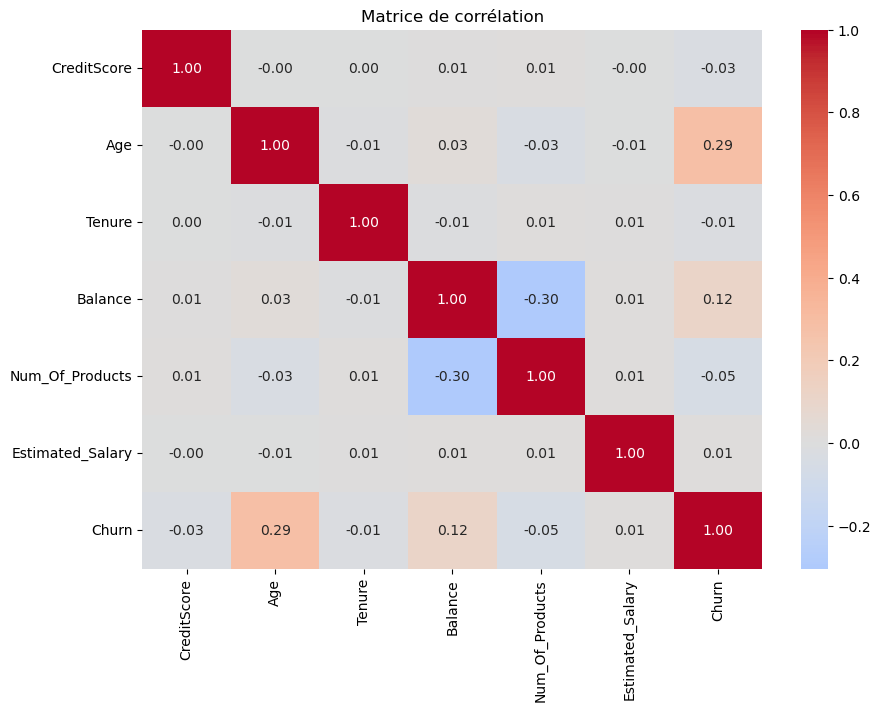

In [85]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation")
plt.show()

- Non. Une corrélation indique une association entre deux variables, mais elle ne permet pas de conclure qu’une variable cause l’autre

# Tests statistiques
# Test 1 — Chi²

In [86]:
from scipy.stats import chi2_contingency

table_genre_churn = pd.crosstab(
    df["Gender"],
    df["Churn"]
)

chi2, p_value, ddl, frequences_attendues = chi2_contingency(
    table_genre_churn
)

print("Chi² :", round(chi2, 4))
print("p-value :", round(p_value, 6))
print("Degrés de liberté :", ddl)

Chi² : 112.9186
p-value : 0.0
Degrés de liberté : 1


- H0 : Gender et Churn sont indépendants.
- H1 : Gender et Churn sont associés.
- p-value < 0.05  (on rejette H0)
- p-value >= 0.05 (on ne rejette pas H0)

# Test t pour Age

In [87]:
from scipy.stats import ttest_ind

age_restes = df.loc[
    df["Churn"] == 0,
    "Age"
]

age_partis = df.loc[
    df["Churn"] == 1,
    "Age"
]

statistique_t, p_value_age = ttest_ind(
    age_restes,
    age_partis,
    equal_var=False
)

print("Statistique t :", round(statistique_t, 4))
print("p-value :", round(p_value_age, 6))

Statistique t : -30.4192
p-value : 0.0


- H0 : les moyennes d'âge sont égales.
- H1 : les moyennes d'âge sont différentes.

# ANOVA

In [88]:
from scipy.stats import f_oneway

groupes_balance = [
    groupe["Balance"].values
    for _, groupe in df.groupby("Geography")
]

statistique_f, p_value_anova = f_oneway(
    *groupes_balance
)

print("Statistique F :", round(statistique_f, 4))
print("p-value :", round(p_value_anova, 6))

Statistique F : 958.4254
p-value : 0.0


- L’ANOVA permet de tester si les moyennes d’une variable quantitative diffèrent significativement entre plusieurs groupes.

# ACP / PCA
# Standardisation

In [89]:
from sklearn.preprocessing import StandardScaler

X_acp = df[variables_numeriques].copy()

scaler_acp = StandardScaler()

X_acp_standardise = scaler_acp.fit_transform(X_acp)

print("Dimensions :", X_acp_standardise.shape)

Dimensions : (10000, 7)


In [90]:
from sklearn.decomposition import PCA

acp = PCA()

X_acp_resultat = acp.fit_transform(
    X_acp_standardise
)

variance_expliquee = acp.explained_variance_ratio_

print("Variance expliquée par composante :")
print(variance_expliquee.round(4))

Variance expliquée par composante :
[0.2019 0.1695 0.1441 0.1428 0.1417 0.1054 0.0946]


# Variance cumulée

In [91]:
variance_cumulee = np.cumsum(
    variance_expliquee
)

table_acp = pd.DataFrame({
    "Composante": [
        f"PC{i+1}"
        for i in range(len(variance_expliquee))
    ],
    "Variance expliquée (%)":
        (variance_expliquee * 100).round(2),
    "Variance cumulée (%)":
        (variance_cumulee * 100).round(2)
})

table_acp

NameError: name 'np' is not defined

# Scree Plot

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(variance_expliquee) + 1),
    variance_expliquee * 100,
    marker="o"
)

plt.title("Variance expliquée par les composantes principales")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (%)")

plt.xticks(
    range(1, len(variance_expliquee) + 1)
)

plt.grid()
plt.show()

# Contributions des variables

In [92]:
loadings = pd.DataFrame(
    acp.components_.T,
    index=variables_numeriques,
    columns=[
        f"PC{i+1}"
        for i in range(acp.n_components_)
    ]
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
CreditScore,-0.045,-0.062,-0.098,0.988,-0.068,-0.014,-0.063
Age,0.433,0.569,-0.032,0.089,0.051,0.564,0.400
Tenure,-0.060,0.000,0.621,0.112,0.773,-0.003,-0.006
Balance,0.543,-0.443,0.057,0.034,-0.005,-0.392,0.592
Num_Of_Products,-0.495,0.506,0.015,0.033,-0.053,-0.489,0.505
Estimated_Salary,0.006,0.017,0.774,0.035,-0.626,0.086,-0.018
Churn,0.517,0.469,0.035,0.019,0.004,-0.530,-0.479


# Projection ACP

In [93]:
acp_2d = pd.DataFrame({
    "PC1": X_acp_resultat[:, 0],
    "PC2": X_acp_resultat[:, 1],
    "Churn": df["Churn"].values
})

acp_2d.head()

,PC1,PC2,Churn
0,0.831677,-1.334534,0
1,0.744503,0.815521,1
2,-0.327048,0.725509,0
3,-0.340719,-1.008437,0
4,0.584328,-0.413323,0


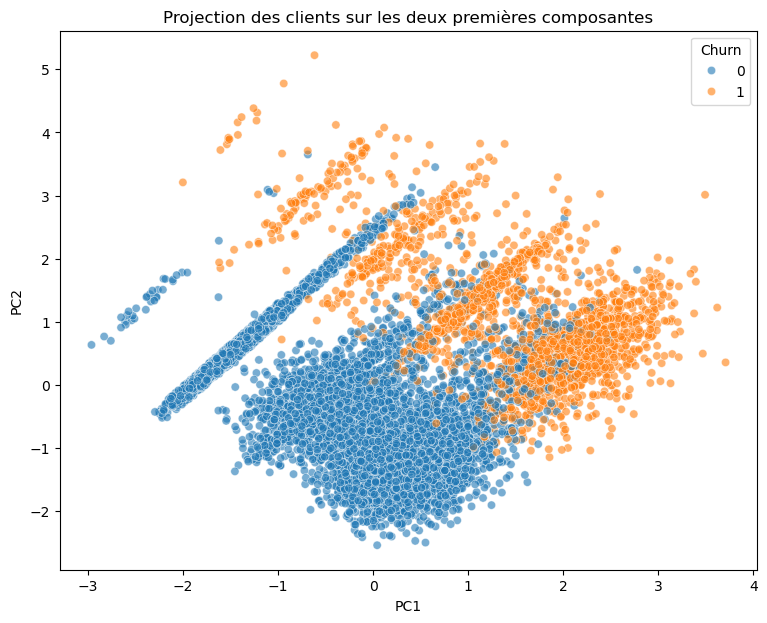

In [94]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=acp_2d,
    x="PC1",
    y="PC2",
    hue="Churn",
    alpha=0.6
)

plt.title("Projection des clients sur les deux premières composantes")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## Détection des Outliers

## IQR Method

In [95]:
variables_outliers = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "Num_Of_Products",
    "Estimated_Salary"
]
resume_outliers = []

for variable in variables_outliers:
    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferieure = Q1 - 1.5 * IQR
    limite_superieure = Q3 + 1.5 * IQR
    
    nombre_outliers = (
        (df[variable] < limite_inferieure) |
        (df[variable] > limite_superieure)
    ).sum()
    
    resume_outliers.append({
        "Variable": variable,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Limite inférieure": limite_inferieure,
        "Limite supérieure": limite_superieure,
        "Nombre outliers": nombre_outliers,
        "Pourcentage (%)": round(
            nombre_outliers / len(df) * 100,
            2
        )
    })

table_outliers = pd.DataFrame(resume_outliers)

table_outliers

,Variable,Q1,Q3,IQR,Limite inférieure,Limite supérieure,Nombre outliers,Pourcentage (%)
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15,0.15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359,3.59
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0,0.00
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0,0.00
4,Num_Of_Products,1.00,2.0000,1.0000,-0.50000,3.50000,60,0.60
5,Estimated_Salary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0,0.00


# Visualisation des Outliers

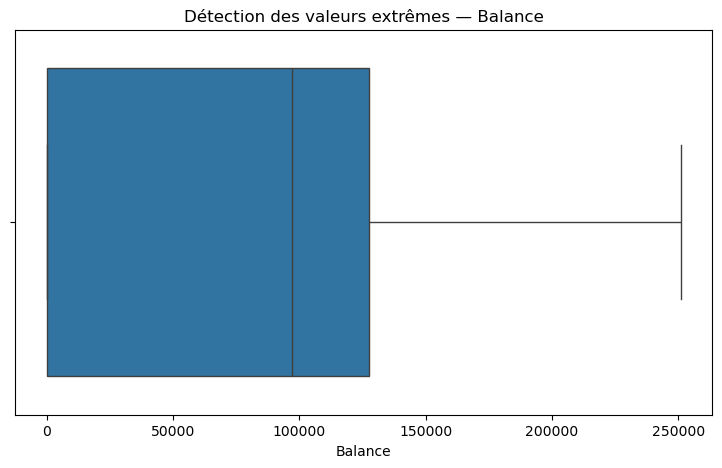

In [96]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Balance"
)

plt.title("Détection des valeurs extrêmes — Balance")
plt.xlabel("Balance")

plt.show()

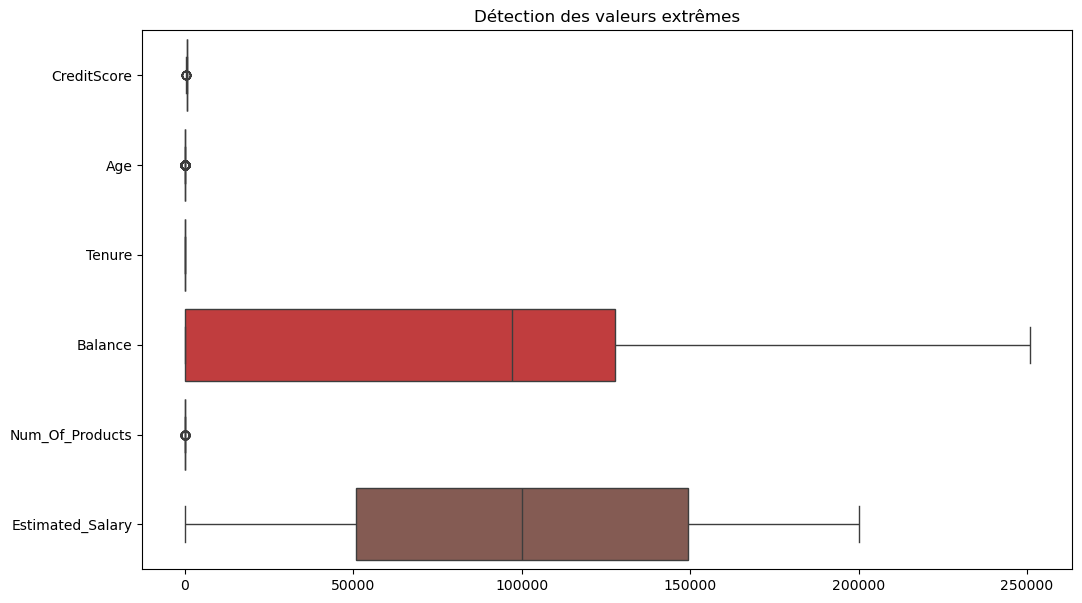

In [97]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df[variables_outliers],
    orient="h"
)

plt.title("Détection des valeurs extrêmes")
plt.show()

- Je n’ai pas supprimé automatiquement les valeurs extrêmes, car dans un contexte bancaire elles peuvent représenter des clients réels et économiquement important

# Machine Learning

# Préparation du Machine Learning
# Définir X et y

In [98]:
variables_ml = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "Num_Of_Products",
    "Has_Credit_Card",
    "Is_Active_Member",
    "Estimated_Salary"
]

X = df[variables_ml].copy()
y = df["Churn"].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (10000, 10)
Dimensions de y : (10000,)


- X = variables explicatives
- y = variable cible

# Vérifier le déséquilibre de la cible

In [99]:
distribution_churn = pd.DataFrame({
    "Nombre": y.value_counts().sort_index(),
    "Pourcentage": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

distribution_churn.index = [
    "Client resté",
    "Client parti"
]

distribution_churn

,Nombre,Pourcentage
Client resté,7963,79.63
Client parti,2037,20.37


# Train / Test Split

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (8000, 10)
X_test  : (2000, 10)
y_train : (8000,)
y_test  : (2000,)


# Définir les variables numériques et catégorielles

# Preprocessing
# Standardisation + One-Hot Encoding

In [107]:
# Variables numériques
variables_numeriques_ml = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "Num_Of_Products",
    "Estimated_Salary"
]

# Variables catégorielles / binaires
variables_categorielles_ml = [
    "Geography",
    "Gender",
    "Has_Credit_Card",
    "Is_Active_Member"
]

# Vérification
print("Variables numériques :", variables_numeriques_ml)
print("Variables catégorielles :", variables_categorielles_ml)

Variables numériques : ['CreditScore', 'Age', 'Tenure', 'Balance', 'Num_Of_Products', 'Estimated_Salary']
Variables catégorielles : ['Geography', 'Gender', 'Has_Credit_Card', 'Is_Active_Member']


In [109]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocesseur = ColumnTransformer(
    transformers=[
        (
            "numerique",
            StandardScaler(),
            variables_numeriques_ml
        ),
        (
            "categorielle",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            variables_categorielles_ml
        )
    ]
)

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


# Cross-Validation

In [110]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Définir les 5 modèles

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [112]:
modeles = {
    "Régression logistique": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Arbre de décision": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# Créer les Pipelines

In [113]:
from sklearn.pipeline import Pipeline

pipelines = {}

for nom, modele in modeles.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocesseur),
            ("model", modele)
        ]
    )

    pipelines[nom] = pipeline

print("Nombre de modèles :", len(pipelines))

Nombre de modèles : 5


# Cross-Validation

In [114]:
from sklearn.model_selection import cross_val_score

resultats_cv = []

for nom, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    resultats_cv.append({
        "Modèle": nom,
        "AUC moyenne": scores.mean(),
        "Écart-type AUC": scores.std()
    })

comparaison_cv = pd.DataFrame(resultats_cv)

comparaison_cv["AUC moyenne"] = (
    comparaison_cv["AUC moyenne"].round(4)
)

comparaison_cv["Écart-type AUC"] = (
    comparaison_cv["Écart-type AUC"].round(4)
)

comparaison_cv.sort_values(
    "AUC moyenne",
    ascending=False
)

,Modèle,AUC moyenne,Écart-type AUC
2,Random Forest,0.8489,0.0119
4,SVM,0.8236,0.0116
3,KNN,0.7798,0.0070
0,Régression logistique,0.7647,0.0080
1,Arbre de décision,0.6908,0.0184


# Entraîner les modèles finaux

In [115]:
for nom, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

print("Les 5 modèles ont été entraînés.")

Les 5 modèles ont été entraînés.


# Predictions

In [116]:
predictions = {}

for nom, pipeline in pipelines.items():
    predictions[nom] = pipeline.predict(X_test)

print("Prédictions terminées.")

Prédictions terminées.


# Accuracy / Precision / Recall / F1

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultats_modeles = []

for nom, pipeline in pipelines.items():

    y_pred = predictions[nom]

    resultats_modeles.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

comparaison_modeles = pd.DataFrame(resultats_modeles)

metriques = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

comparaison_modeles[metriques] = (
    comparaison_modeles[metriques].round(4)
)

comparaison_modeles.sort_values(
    "F1",
    ascending=False
)

,Modèle,Accuracy,Precision,Recall,F1
2,Random Forest,0.8705,0.7782,0.5086,0.6152
3,KNN,0.8525,0.6905,0.4988,0.5792
4,SVM,0.8665,0.8211,0.4398,0.5728
1,Arbre de décision,0.7775,0.4581,0.5111,0.4832
0,Régression logistique,0.8135,0.6012,0.2482,0.3513


# ROC-AUC

In [118]:
from sklearn.metrics import roc_auc_score

resultats_auc = []

for nom, pipeline in pipelines.items():

    probabilites = pipeline.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        probabilites
    )

    resultats_auc.append({
        "Modèle": nom,
        "AUC": auc
    })

comparaison_auc = pd.DataFrame(resultats_auc)

comparaison_auc["AUC"] = (
    comparaison_auc["AUC"].round(4)
)

comparaison_auc.sort_values(
    "AUC",
    ascending=False
)

,Modèle,AUC
2,Random Forest,0.8748
4,SVM,0.8644
3,KNN,0.8133
0,Régression logistique,0.7648
1,Arbre de décision,0.6783


# Comparaison finale

In [119]:
comparaison_finale = comparaison_modeles.merge(
    comparaison_auc,
    on="Modèle"
)

comparaison_finale = comparaison_finale.sort_values(
    "AUC",
    ascending=False
)

comparaison_finale

,Modèle,Accuracy,Precision,Recall,F1,AUC
2,Random Forest,0.8705,0.7782,0.5086,0.6152,0.8748
4,SVM,0.8665,0.8211,0.4398,0.5728,0.8644
3,KNN,0.8525,0.6905,0.4988,0.5792,0.8133
0,Régression logistique,0.8135,0.6012,0.2482,0.3513,0.7648
1,Arbre de décision,0.7775,0.4581,0.5111,0.4832,0.6783


# ROC Curves

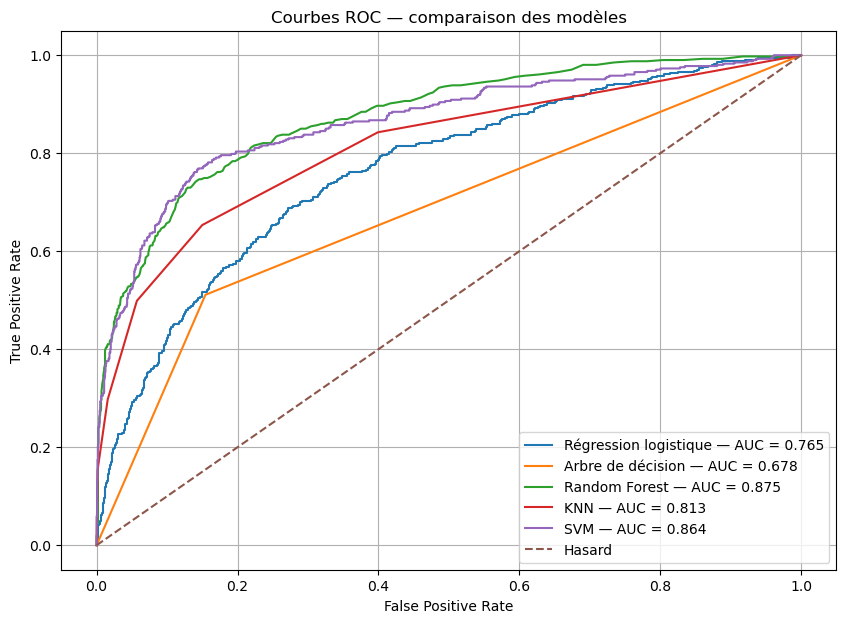

In [120]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for nom, pipeline in pipelines.items():

    probabilites = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilites
    )

    auc = roc_auc_score(
        y_test,
        probabilites
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nom} — AUC = {auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Hasard"
)

plt.title("Courbes ROC — comparaison des modèles")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

- La courbe ROC représente le compromis entre le taux de vrais positifs et le taux de faux positifs pour différents seuils de classification. 

- Plus l’AUC est proche de 1, meilleure est la capacité discriminante du modèle

# Choisir le meilleur modèle

In [121]:
meilleur_modele_nom = comparaison_auc.loc[
    comparaison_auc["AUC"].idxmax(),
    "Modèle"
]

meilleur_modele_auc = comparaison_auc["AUC"].max()

print("Meilleur modèle :", meilleur_modele_nom)
print("AUC :", round(meilleur_modele_auc, 4))

Meilleur modèle : Random Forest
AUC : 0.8748


# Confusion Matrix

In [122]:
from sklearn.metrics import confusion_matrix

meilleur_modele = pipelines[meilleur_modele_nom]

y_pred_meilleur = meilleur_modele.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_meilleur
)

cm

array([[1534,   59],
       [ 200,  207]])

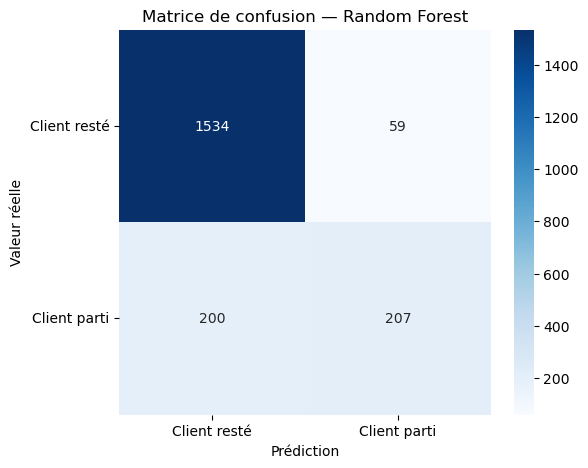

In [123]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Matrice de confusion — {meilleur_modele_nom}"
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.xticks(
    [0.5, 1.5],
    ["Client resté", "Client parti"]
)

plt.yticks(
    [0.5, 1.5],
    ["Client resté", "Client parti"],
    rotation=0
)

plt.show()

# Classification Report

In [124]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_meilleur,
        target_names=[
            "Client resté",
            "Client parti"
        ]
    )
)

              precision    recall  f1-score   support

Client resté       0.88      0.96      0.92      1593
Client parti       0.78      0.51      0.62       407

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



# Feature Importance

In [126]:
modele_rf = pipelines["Random Forest"]

In [127]:
noms_features = (
    modele_rf
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

importances = (
    modele_rf
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Variable": noms_features,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Variable,Importance
1,numerique__Age,0.240406
5,numerique__Estimated_Salary,0.149437
0,numerique__CreditScore,0.144520
3,numerique__Balance,0.141775
4,numerique__Num_Of_Products,0.123932
2,numerique__Tenure,0.082218
10,categorielle__Is_Active_Member_1,0.040849
6,categorielle__Geography_Germany,0.025765
8,categorielle__Gender_Male,0.018795
9,categorielle__Has_Credit_Card_1,0.018643


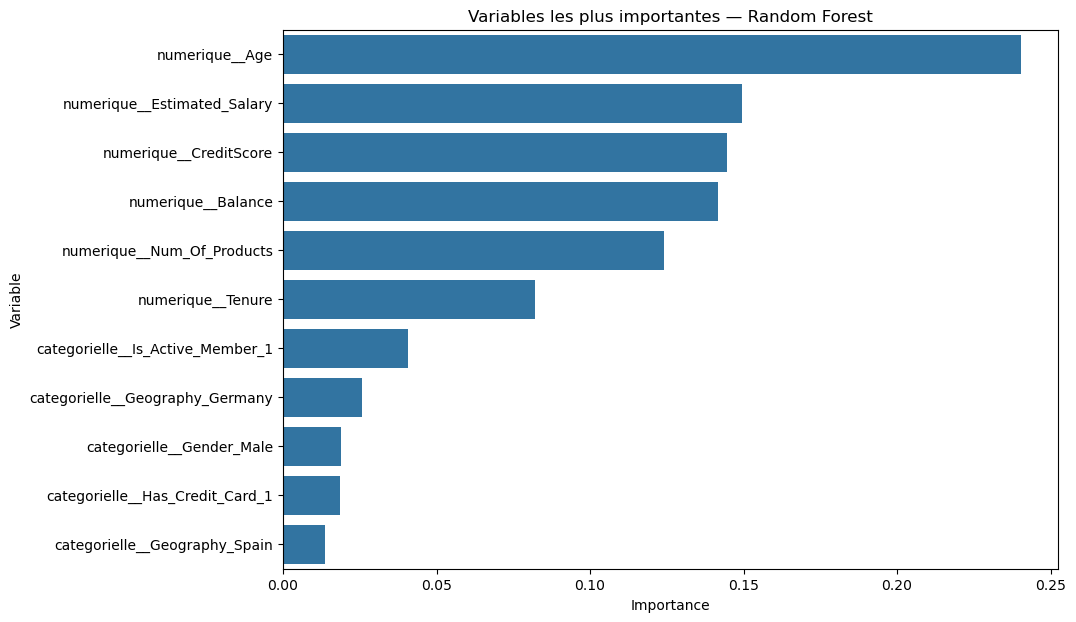

In [128]:
top_importances = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importances,
    x="Importance",
    y="Variable"
)

plt.title(
    "Variables les plus importantes — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Variable")

plt.show()

# Tuning du meilleur modèle

In [129]:
comparaison_auc.sort_values(
    "AUC",
    ascending=False
)

,Modèle,AUC
2,Random Forest,0.8748
4,SVM,0.8644
3,KNN,0.8133
0,Régression logistique,0.7648
1,Arbre de décision,0.6783


# Random Forest — GridSearchCV

In [130]:
from sklearn.model_selection import GridSearchCV

pipeline_rf = Pipeline(
    steps=[
        ("preprocessing", preprocesseur),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [132]:
parametres_rf = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametres_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [200, 300]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerique', ...), ('categorielle', ...)]"


# Best parameters

In [133]:
print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print(
    "Meilleur AUC CV :",
    round(grid_rf.best_score_, 4)
)

Meilleurs paramètres :
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Meilleur AUC CV : 0.8565


# Evaluate tuned model

In [134]:
modele_rf_tuned = grid_rf.best_estimator_

probabilites_rf_tuned = (
    modele_rf_tuned.predict_proba(X_test)[:, 1]
)

auc_rf_tuned = roc_auc_score(
    y_test,
    probabilites_rf_tuned
)

print(
    "AUC Random Forest après tuning :",
    round(auc_rf_tuned, 4)
)

AUC Random Forest après tuning : 0.8823


In [135]:
auc_rf_avant = comparaison_auc.loc[
    comparaison_auc["Modèle"] == "Random Forest",
    "AUC"
].iloc[0]

print("AUC avant tuning :", round(auc_rf_avant, 4))
print("AUC après tuning :", round(auc_rf_tuned, 4))
print(
    "Amélioration :",
    round(auc_rf_tuned - auc_rf_avant, 4)
)

AUC avant tuning : 0.8748
AUC après tuning : 0.8823
Amélioration : 0.0075


# ROC du modèle final

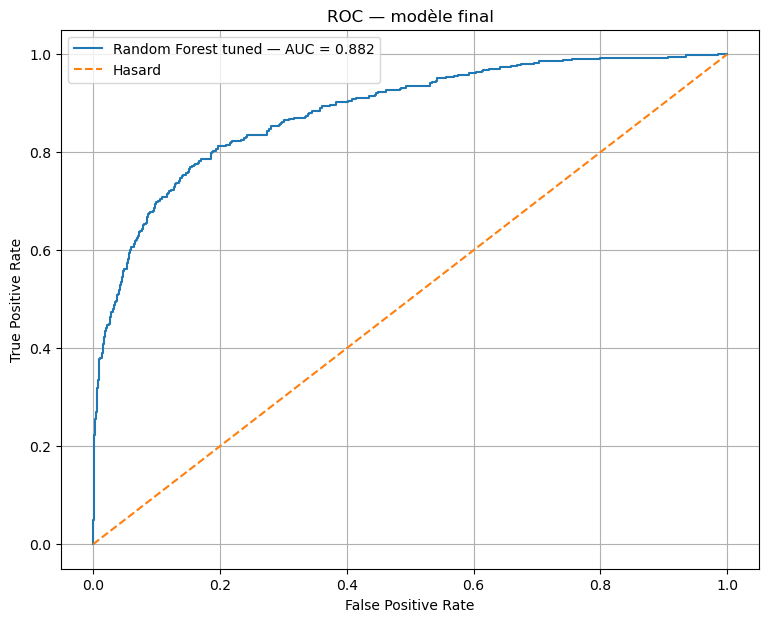

In [136]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    probabilites_rf_tuned
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest tuned — AUC = {auc_rf_tuned:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Hasard"
)

plt.title("ROC — modèle final")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

# Business Threshold

In [137]:
seuil = 0.40

y_pred_seuil = (
    probabilites_rf_tuned >= seuil
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_seuil,
        target_names=[
            "Client resté",
            "Client parti"
        ]
    )
)

              precision    recall  f1-score   support

Client resté       0.89      0.95      0.92      1593
Client parti       0.75      0.56      0.64       407

    accuracy                           0.87      2000
   macro avg       0.82      0.75      0.78      2000
weighted avg       0.86      0.87      0.86      2000



# Export des résultats ML

In [141]:
# ============================================================
# ACP / PCA + EXPORTATION DES RÉSULTATS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 1. Variables utilisées pour l'ACP
# ------------------------------------------------------------

variables_numeriques_acp = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "Num_Of_Products",
    "Estimated_Salary"
]


# ------------------------------------------------------------
# 2. Préparation des données
# ------------------------------------------------------------

X_acp = df[variables_numeriques_acp].copy()


# ------------------------------------------------------------
# 3. Standardisation
# ------------------------------------------------------------

scaler_acp = StandardScaler()

X_acp_standardise = scaler_acp.fit_transform(X_acp)


# ------------------------------------------------------------
# 4. Application de l'ACP
# ------------------------------------------------------------

acp = PCA()

X_acp_resultat = acp.fit_transform(X_acp_standardise)


# ------------------------------------------------------------
# 5. Variance expliquée
# ------------------------------------------------------------

variance_expliquee = acp.explained_variance_ratio_

variance_cumulee = np.cumsum(variance_expliquee)


# ------------------------------------------------------------
# 6. Création de la table ACP
# ------------------------------------------------------------

table_acp = pd.DataFrame({
    "Composante": [
        f"PC{i+1}" for i in range(len(variance_expliquee))
    ],
    "Variance expliquée (%)": (
        variance_expliquee * 100
    ).round(2),
    "Variance cumulée (%)": (
        variance_cumulee * 100
    ).round(2)
})


# ------------------------------------------------------------
# 7. Affichage des résultats
# ------------------------------------------------------------

print("=== Résultats de l'ACP ===")

display(table_acp)


# ------------------------------------------------------------
# 8. Exportation des résultats ACP
# ------------------------------------------------------------

table_acp.to_csv(
    "resultats_acp_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


print("Fichier ACP exporté avec succès.")

=== Résultats de l'ACP ===


,Composante,Variance expliquée (%),Variance cumulée (%)
0,PC1,21.85,21.85
1,PC2,16.89,38.74
2,PC3,16.69,55.43
3,PC4,16.54,71.97
4,PC5,16.47,88.43
5,PC6,11.57,100.00


Fichier ACP exporté avec succès.


In [142]:
# ============================================================
# EXPORTATION DES RÉSULTATS DU PROJET
# ============================================================

# ------------------------------------------------------------
# 1. Créer la table des résultats de l'ACP
# ------------------------------------------------------------

table_acp = pd.DataFrame({
    "Composante": [
        f"PC{i+1}" for i in range(len(variance_expliquee))
    ],
    "Variance expliquée (%)": variance_expliquee * 100,
    "Variance cumulée (%)": variance_cumulee * 100
})


# ------------------------------------------------------------
# 2. Exportation de la comparaison des modèles
# ------------------------------------------------------------

comparaison_finale.to_csv(
    "comparaison_modeles_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 3. Exportation de la validation croisée
# ------------------------------------------------------------

comparaison_cv.to_csv(
    "cross_validation_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 4. Exportation de l'importance des variables
# ------------------------------------------------------------

importance_df.to_csv(
    "importance_variables_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 5. Exportation de l'analyse des valeurs aberrantes
# ------------------------------------------------------------

table_outliers.to_csv(
    "analyse_outliers_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. Exportation des résultats de l'ACP
# ------------------------------------------------------------

table_acp.to_csv(
    "resultats_acp_attrition.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. Confirmation
# ------------------------------------------------------------

print("Tous les fichiers ont été exportés avec succès.")

Tous les fichiers ont été exportés avec succès.


In [143]:
import os
import pandas as pd

# ============================================================
# VÉRIFICATION DES FICHIERS EXPORTÉS
# ============================================================

fichiers = [
    "comparaison_modeles_attrition.csv",
    "cross_validation_attrition.csv",
    "importance_variables_attrition.csv",
    "analyse_outliers_attrition.csv",
    "resultats_acp_attrition.csv"
]

print("=== VÉRIFICATION DES FICHIERS ===\n")

for fichier in fichiers:
    
    if os.path.exists(fichier):
        taille = os.path.getsize(fichier) / 1024
        
        print(f"✓ {fichier}")
        print(f"  Taille : {taille:.2f} KB")
        
        # Vérification rapide du contenu
        try:
            data_test = pd.read_csv(fichier, encoding="utf-8-sig")
            print(f"  Lignes : {data_test.shape[0]}")
            print(f"  Colonnes : {data_test.shape[1]}")
            print()
            
        except Exception as e:
            print(f"  ⚠ Erreur de lecture : {e}\n")
    
    else:
        print(f"✗ FICHIER MANQUANT : {fichier}\n")

=== VÉRIFICATION DES FICHIERS ===

✓ comparaison_modeles_attrition.csv
  Taille : 0.28 KB
  Lignes : 5
  Colonnes : 6

✓ cross_validation_attrition.csv
  Taille : 0.17 KB
  Lignes : 5
  Colonnes : 3

✓ importance_variables_attrition.csv
  Taille : 0.52 KB
  Lignes : 11
  Colonnes : 2

✓ analyse_outliers_attrition.csv
  Taille : 0.42 KB
  Lignes : 6
  Colonnes : 8

✓ resultats_acp_attrition.csv
  Taille : 0.29 KB
  Lignes : 6
  Colonnes : 3



## Conclusion finale

Ce projet avait pour objectif d’analyser l’attrition des clients d’une banque et d’identifier les principaux facteurs associés au départ des clients.

L’analyse a commencé par une étape de préparation et de contrôle de la qualité des données, afin de vérifier la structure de la base, les valeurs manquantes, les doublons et la cohérence des variables. Les analyses descriptives ont ensuite permis de mieux comprendre le profil des clients selon leur âge, leur situation géographique, leur score de crédit, leur solde bancaire, leur ancienneté, leur salaire estimé, leur nombre de produits et leur niveau d’activité.

Les analyses statistiques ont permis d’étudier les relations entre certaines variables et l’attrition. Les tests du Chi², les tests de comparaison de moyennes et l’ANOVA ont apporté une dimension statistique à l’analyse et ont permis de distinguer les simples différences observées des relations statistiquement significatives.

Une analyse des valeurs aberrantes a également été réalisée. Les valeurs extrêmes n’ont pas été supprimées automatiquement, car dans un contexte bancaire, elles peuvent correspondre à des clients réels ayant des soldes, des revenus ou des caractéristiques particulières.

L’Analyse en Composantes Principales (ACP) a ensuite permis d’étudier la structure des variables numériques et la quantité d’information expliquée par les différentes composantes principales. Cette étape a principalement servi à mieux comprendre la structure des données avant la modélisation.

Enfin, une approche de Machine Learning a été mise en place afin de prédire l’attrition des clients. Cinq modèles ont été comparés : la Régression Logistique, l’Arbre de Décision, le Random Forest, le KNN et le SVM. Les modèles ont été évalués à l’aide de plusieurs indicateurs, notamment l’Accuracy, la Precision, le Recall, le F1-score et surtout l’AUC-ROC.

Cette comparaison permet d’identifier le modèle offrant le meilleur compromis entre performance statistique et capacité à distinguer les clients susceptibles de quitter la banque.

D’un point de vue métier, l’objectif n’est pas uniquement de prédire quels clients pourraient partir, mais surtout de permettre à la banque d’agir de manière préventive. Les résultats peuvent ainsi aider à identifier les profils de clients nécessitant une attention particulière et à mettre en place des actions ciblées telles que des offres personnalisées, des campagnes de fidélisation ou une amélioration de l’engagement des clients inactifs.

En conclusion, ce projet montre comment une démarche complète de Data Analytics, allant de SQL à Python, en passant par les statistiques, l’ACP et le Machine Learning, peut transformer des données bancaires en informations utiles à la prise de décision.

La prochaine étape consiste à présenter ces résultats de manière interactive dans Power BI afin de construire un tableau de bord professionnel permettant aux responsables bancaires d’explorer les profils des clients et les facteurs associés à l’attrition.
